In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c quora-question-pairs

 95% 292M/309M [00:00<00:00, 811MB/s] 
100% 309M/309M [00:00<00:00, 882MB/s]


In [ ]:
!unzip quora-question-pairs.zip

Archive:  quora-question-pairs.zip
  inflating: sample_submission.csv.zip  
  inflating: test.csv                
  inflating: test.csv.zip            
  inflating: train.csv.zip           


In [ ]:
!pip install distance

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.3/180.3 kB 17.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for distance: filename=Distance-0.1.3-py3-none-any.whl size=16256 sha256=49ea4e84cbef7d71a92935ebfa5458f9ac375678b7bb6c6ab4c1fbca2519875a
  Stored in directory: /root/.cache/pip/wheels/24/a8/58/407063d8e5c1d4dd6594c99d12baa0108570b56a92325587dd
Successfully built distance


In [ ]:
!unzip train.csv.zip

Archive:  train.csv.zip
  inflating: train.csv               


In [ ]:
import numpy as np
import pandas as pd
import distance
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
import gc

In [ ]:
new_df = pd.read_csv("train.csv")
new_df.shape

(404290, 6)

In [ ]:
new_df.sample(10)

,id,qid1,qid2,question1,question2,is_duplicate
270534,270534,388448,13898,How do I eat food mindfully?,How can I eat food?,1
396571,396571,27618,67855,How does banning 500 and 1000 rupee notes help...,"By scrapping the 500 and 1000 rupee notes, how...",1
388153,388153,520523,520524,Why do people drive above the speed limit?,If you were in a car chase and someone was sho...,0
125144,125144,201945,201946,By not replying to all Nonsense of Arvind kejr...,"What is the poem ""Crutches"" by Bertolt Brecht ...",0
90179,90179,151370,63005,What are your recommendations for self-studyin...,What are your recommendations for self-studyin...,1
103078,103078,41706,170451,When does a woman have the highest chance of g...,What are the chances of getting pregnant if on...,0
215207,215207,25818,23986,Which is the best phone under ₹15000?,Which is the best phone to buy within Rs.15000?,1
205653,205653,32481,249862,How do you like China?,Do you like China? And why?,1
141291,141291,199003,224339,Why is the complexity of BFS not o(V*E)?,Why is the time complexity of BFS O(V+E)?,1
284725,284725,405036,405037,I have a score of 504 and a rank of 6077 in GA...,I got an Air 358 in the GATE EE paper. I am in...,0


In [ ]:
print(new_df.isnull().sum())
new_df.dropna(inplace=True)

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64


In [ ]:
print(new_df.duplicated().sum())
print(new_df.isnull().sum())

0
id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64


is_duplicate
0    255024
1    149263
Name: count, dtype: int64
is_duplicate
0    63.079941
1    36.920059
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

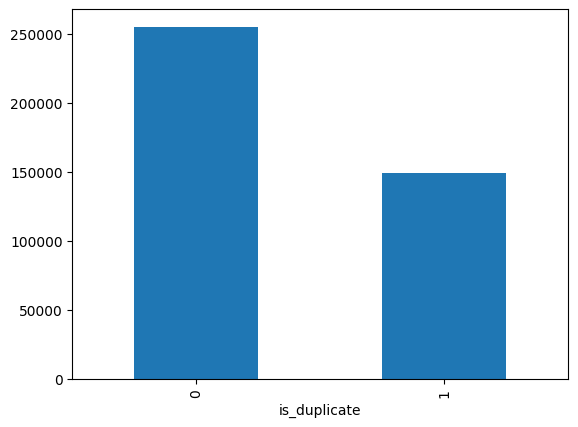

In [ ]:
print(new_df['is_duplicate'].value_counts())
print((new_df['is_duplicate'].value_counts()/new_df['is_duplicate'].count())*100)
new_df['is_duplicate'].value_counts().plot(kind='bar')

In [ ]:
# Repeated questions
qid = pd.Series(new_df['qid1'].tolist() + new_df['qid2'].tolist())
print('Number of unique questions',np.unique(qid).shape[0])
x = qid.value_counts()>1
print('Number of questions getting repeated',x[x].shape[0])

Number of unique questions 537929
Number of questions getting repeated 111778


In [ ]:
import re
from bs4 import BeautifulSoup

# ✅ Move outside function - built only ONCE instead of for every row
CONTRACTIONS = {
    "ain't": "am not",
    "aren't": "are not",
    "can't": "can not",
    "can't've": "can not have",
    "'cause": "because",
    "could've": "could have",
    "couldn't": "could not",
    "couldn't've": "could not have",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hadn't've": "had not have",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'd've": "he would have",
    "he'll": "he will",
    "he'll've": "he will have",
    "he's": "he is",
    "how'd": "how did",
    "how'd'y": "how do you",
    "how'll": "how will",
    "how's": "how is",
    "i'd": "i would",
    "i'd've": "i would have",
    "i'll": "i will",
    "i'll've": "i will have",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it'd": "it would",
    "it'd've": "it would have",
    "it'll": "it will",
    "it'll've": "it will have",
    "it's": "it is",
    "let's": "let us",
    "ma'am": "madam",
    "mayn't": "may not",
    "might've": "might have",
    "mightn't": "might not",
    "mightn't've": "might not have",
    "must've": "must have",
    "mustn't": "must not",
    "mustn't've": "must not have",
    "needn't": "need not",
    "needn't've": "need not have",
    "o'clock": "of the clock",
    "oughtn't": "ought not",
    "oughtn't've": "ought not have",
    "shan't": "shall not",
    "sha'n't": "shall not",
    "shan't've": "shall not have",
    "she'd": "she would",
    "she'd've": "she would have",
    "she'll": "she will",
    "she'll've": "she will have",
    "she's": "she is",
    "should've": "should have",
    "shouldn't": "should not",
    "shouldn't've": "should not have",
    "so've": "so have",
    "so's": "so as",
    "that'd": "that would",
    "that'd've": "that would have",
    "that's": "that is",
    "there'd": "there would",
    "there'd've": "there would have",
    "there's": "there is",
    "they'd": "they would",
    "they'd've": "they would have",
    "they'll": "they will",
    "they'll've": "they will have",
    "they're": "they are",
    "they've": "they have",
    "to've": "to have",
    "wasn't": "was not",
    "we'd": "we would",
    "we'd've": "we would have",
    "we'll": "we will",
    "we'll've": "we will have",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what'll": "what will",
    "what'll've": "what will have",
    "what're": "what are",
    "what's": "what is",
    "what've": "what have",
    "when's": "when is",
    "when've": "when have",
    "where'd": "where did",
    "where's": "where is",
    "where've": "where have",
    "who'll": "who will",
    "who'll've": "who will have",
    "who's": "who is",
    "who've": "who have",
    "why's": "why is",
    "why've": "why have",
    "will've": "will have",
    "won't": "will not",
    "won't've": "will not have",
    "would've": "would have",
    "wouldn't": "would not",
    "wouldn't've": "would not have",
    "y'all": "you all",
    "y'all'd": "you all would",
    "y'all'd've": "you all would have",
    "y'all're": "you all are",
    "y'all've": "you all have",
    "you'd": "you would",
    "you'd've": "you would have",
    "you'll": "you will",
    "you'll've": "you will have",
    "you're": "you are",
    "you've": "you have"
}

def preprocess(q):

    q = str(q).lower().strip()

    # Symbol normalization
    q = q.replace('%', ' percent')
    q = q.replace('$', ' dollar ')
    q = q.replace('₹', ' rupee ')
    q = q.replace('€', ' euro ')
    q = q.replace('@', ' at ')
    q = q.replace('[math]', '')

    # Number normalization
    q = q.replace(',000,000,000 ', 'b ')
    q = q.replace(',000,000 ', 'm ')
    q = q.replace(',000 ', 'k ')
    q = re.sub(r'([0-9]+)000000000', r'\1b', q)
    q = re.sub(r'([0-9]+)000000', r'\1m', q)
    q = re.sub(r'([0-9]+)000', r'\1k', q)

    # Contraction expansion - ✅ using global CONTRACTIONS dict
    q_decontracted = []
    for word in q.split():
        if word in CONTRACTIONS:
            word = CONTRACTIONS[word]
        q_decontracted.append(word)

    q = ' '.join(q_decontracted)
    q = q.replace("'ve", " have")
    q = q.replace("n't", " not")
    q = q.replace("'re", " are")
    q = q.replace("'ll", " will")

    # ✅ Fix - only use BeautifulSoup when HTML tags exist
    if '<' in q and '>' in q:
        q = BeautifulSoup(q, 'html.parser').get_text()

    # Remove punctuations
    pattern = re.compile(r'\W')
    q = re.sub(pattern, ' ', q).strip()

    # Collapse multiple spaces
    q = ' '.join(q.split())

    return q

In [ ]:
new_df['question1'] = new_df['question1'].apply(preprocess)
new_df['question2'] = new_df['question2'].apply(preprocess)
new_df.sample(5)

,id,qid1,qid2,question1,question2,is_duplicate
341965,341965,469878,469879,what is it like to commit genocide,is isis committing genocide,0
282236,282236,11925,402138,how much does youtube pay per view,how much commission does skyscanner travel api...,0
226175,226175,58343,186961,how can i overcome the fear of public speaking,how can i overcome my fear of public speaking,1
32940,32940,60582,60583,what inspirational books have most changed you...,which is the most inspirational book to change...,0
392702,392702,475506,121045,what is ham radio and what is it used for,what is amateur radio,0


In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 79.7 MB/s eta 0:00:00


In [ ]:
from gensim.models import Word2Vec

# Prepare sentences from both questions
sentences = [q.split() for q in list(new_df['question1']) + list(new_df['question2'])]

# Train Word2Vec
w2v_model = Word2Vec(
    sentences,
    vector_size=300,
    window=5,
    min_count=1,
    workers=4,
    epochs=20
)

# Helper function
def get_sentence_vector(sentence, model):
    words = sentence.split()
    vectors = [model.wv[w] for w in words if w in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(300)

In [ ]:
# Feature Engineering

new_df['q1_len'] = new_df['question1'].str.len()
new_df['q2_len'] = new_df['question2'].str.len()

In [ ]:
new_df['q1_num_words'] = new_df['question1'].apply(lambda row: len(row.split(" ")))
new_df['q2_num_words'] = new_df['question2'].apply(lambda row: len(row.split(" ")))

In [ ]:
def common_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return len(w1 & w2)

In [ ]:
new_df['word_common'] = new_df.apply(common_words, axis=1)

In [ ]:
def total_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return (len(w1) + len(w2))

In [ ]:
new_df['word_total'] = new_df.apply(total_words, axis=1)

In [ ]:
new_df['word_share'] = round(new_df['word_common']/new_df['word_total'],2)
new_df.sample(5)

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share
182593,182593,240739,46553,what does it mean when imessage does not say d...,on imessage if a message says delivered is the...,0,54,87,10,17,2,25,0.08
146175,146175,230966,230967,what is going on my instagram account the most,what social media platform tells me who are th...,0,46,112,9,19,7,28,0.25
395055,395055,527998,527999,what bible app can be used without an internet...,is it possible to watch a movie on an ipad wit...,0,57,70,10,13,4,23,0.17
311021,311021,435236,435237,what is the meaning of the song taro by alt j,what genre is the song garden of england by alt j,0,45,49,11,11,8,21,0.38
295288,295288,297565,317333,small business ideas,ideas for a small buisness,1,20,26,3,5,2,8,0.25


In [ ]:
# Advanced Features
from nltk.corpus import stopwords

def fetch_token_features(row):

    q1 = row['question1']
    q2 = row['question2']

    SAFE_DIV = 0.0001

    STOP_WORDS = stopwords.words("english")

    token_features = [0.0]*8

    # Converting the Sentence into Tokens:
    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features

    # Get the non-stopwords in Questions
    q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])

    #Get the stopwords in Questions
    q1_stops = set([word for word in q1_tokens if word in STOP_WORDS])
    q2_stops = set([word for word in q2_tokens if word in STOP_WORDS])

    # Get the common non-stopwords from Question pair
    common_word_count = len(q1_words.intersection(q2_words))

    # Get the common stopwords from Question pair
    common_stop_count = len(q1_stops.intersection(q2_stops))

    # Get the common Tokens from Question pair
    common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))


    token_features[0] = common_word_count / (min(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[1] = common_word_count / (max(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[2] = common_stop_count / (min(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[3] = common_stop_count / (max(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[4] = common_token_count / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    token_features[5] = common_token_count / (max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)

    # Last word of both question is same or not
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])

    # First word of both question is same or not
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])

    return token_features

In [ ]:
import nltk
nltk.download('stopwords')

token_features = new_df.apply(fetch_token_features, axis=1)

new_df["cwc_min"]       = list(map(lambda x: x[0], token_features))
new_df["cwc_max"]       = list(map(lambda x: x[1], token_features))
new_df["csc_min"]       = list(map(lambda x: x[2], token_features))
new_df["csc_max"]       = list(map(lambda x: x[3], token_features))
new_df["ctc_min"]       = list(map(lambda x: x[4], token_features))
new_df["ctc_max"]       = list(map(lambda x: x[5], token_features))
new_df["last_word_eq"]  = list(map(lambda x: x[6], token_features))
new_df["first_word_eq"] = list(map(lambda x: x[7], token_features))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def fetch_length_features(row):
    q1 = row['question1']
    q2 = row['question2']

    length_features = [0.0]*3

    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return length_features

    # Absolute length features
    length_features[0] = abs(len(q1_tokens) - len(q2_tokens))

    # Average Token Length
    length_features[1] = (len(q1_tokens) + len(q2_tokens)) / 2

    # Longest substring ratio
    strs = list(distance.lcsubstrings(q1, q2))
    length_features[2] = len(strs[0]) / (min(len(q1), len(q2)) + 1) if len(strs) > 0 else 0  # ✅ fixed

    return length_features

In [ ]:
length_features = new_df.apply(fetch_length_features, axis=1)

new_df['abs_len_diff'] = list(map(lambda x: x[0], length_features))
new_df['mean_len'] = list(map(lambda x: x[1], length_features))
new_df['longest_substr_ratio'] = list(map(lambda x: x[2], length_features))

In [ ]:
!pip install fuzzywuzzy python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 117.2 MB/s eta 0:00:00


In [ ]:
# Fuzzy Features
from fuzzywuzzy import fuzz

def fetch_fuzzy_features(row):

    q1 = row['question1']
    q2 = row['question2']

    fuzzy_features = [0.0]*4

    # fuzz_ratio
    fuzzy_features[0] = fuzz.QRatio(q1, q2)

    # fuzz_partial_ratio
    fuzzy_features[1] = fuzz.partial_ratio(q1, q2)

    # token_sort_ratio
    fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)

    # token_set_ratio
    fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)

    return fuzzy_features

In [ ]:
fuzzy_features = new_df.apply(fetch_fuzzy_features, axis=1)

# Creating new feature columns for fuzzy features
new_df['fuzz_ratio'] = list(map(lambda x: x[0], fuzzy_features))
new_df['fuzz_partial_ratio'] = list(map(lambda x: x[1], fuzzy_features))
new_df['token_sort_ratio'] = list(map(lambda x: x[2], fuzzy_features))
new_df['token_set_ratio'] = list(map(lambda x: x[3], fuzzy_features))

print(new_df.shape)
new_df.head()

(404287, 36)


,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56,14,12,...,0.785709,0.0,1.0,2.0,13.0,0.982456,93,100,93,100
1,1,3,4,what is the story of kohinoor koh i noor diamond,what would happen if the indian government sto...,0,48,85,10,15,...,0.466664,0.0,1.0,5.0,12.5,0.571429,65,73,63,86
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58,14,10,...,0.285712,0.0,1.0,4.0,12.0,0.169492,54,53,66,66
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divided ...,0,48,54,11,12,...,0.000000,0.0,0.0,1.0,11.5,0.040816,35,38,37,36
4,4,9,10,which one dissolve in water quikly sugar salt ...,which fish would survive in salt water,0,73,38,13,7,...,0.307690,0.0,1.0,6.0,10.0,0.153846,45,55,47,67


In [ ]:
import os
print(os.cpu_count())

2


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

# Get sentence vectors
new_df['q1_vec'] = new_df['question1'].apply(lambda x: get_sentence_vector(x, w2v_model))
new_df['q2_vec'] = new_df['question2'].apply(lambda x: get_sentence_vector(x, w2v_model))

# Derive scalar similarity features (DO NOT dump raw vectors into model)
new_df['w2v_cosine']    = new_df.apply(lambda r: cos_sim([r['q1_vec']], [r['q2_vec']])[0][0], axis=1)
new_df['w2v_euclidean'] = new_df.apply(lambda r: np.linalg.norm(r['q1_vec'] - r['q2_vec']), axis=1)
new_df['w2v_dot']       = new_df.apply(lambda r: np.dot(r['q1_vec'], r['q2_vec']), axis=1)
new_df['w2v_manhattan'] = new_df.apply(lambda r: np.sum(np.abs(r['q1_vec'] - r['q2_vec'])), axis=1)

# Add after your existing w2v features

# Difference vector norm (captures asymmetry)
new_df['w2v_diff_norm'] = new_df.apply(
    lambda r: np.linalg.norm(r['q1_vec'] - r['q2_vec']) /
              (np.linalg.norm(r['q1_vec']) + np.linalg.norm(r['q2_vec']) + 0.0001),
    axis=1
)

# Ratio of vector magnitudes
new_df['w2v_len_ratio'] = new_df.apply(
    lambda r: np.linalg.norm(r['q1_vec']) /
              (np.linalg.norm(r['q2_vec']) + 0.0001),
    axis=1
)

# Chebyshev distance (max difference across any single dimension)
new_df['w2v_chebyshev'] = new_df.apply(
    lambda r: np.max(np.abs(r['q1_vec'] - r['q2_vec'])),
    axis=1
)

# Drop raw vectors - not needed anymore
new_df.drop(columns=['q1_vec', 'q2_vec'], inplace=True)

In [ ]:
final_df = new_df.drop(columns=['id','qid1','qid2','question1','question2'])
final_df = final_df.reset_index(drop=True)
print(final_df.shape)
final_df.sample(5)
#30 -> 38

(404287, 38)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,q1_degree,q2_degree,...,fuzz_partial_ratio,token_sort_ratio,token_set_ratio,w2v_cosine,w2v_euclidean,w2v_dot,w2v_manhattan,w2v_diff_norm,w2v_len_ratio,w2v_chebyshev
266009,1,45,21,9,5,3,14,0.21,5,9,...,71,58,86,0.590161,7.438947,38.824562,103.686737,0.457348,0.863723,1.114572
216362,1,41,43,8,9,7,17,0.41,1,1,...,71,88,95,0.938409,2.940735,64.497681,39.984859,0.177298,1.052715,0.561127
206337,0,39,56,6,10,5,16,0.31,1,1,...,92,74,95,0.750527,7.178713,73.416191,97.578285,0.361654,1.181488,1.223652
325620,1,52,68,11,14,6,25,0.24,9,3,...,52,63,70,0.804191,4.970168,48.555214,70.397980,0.319118,0.876108,0.925545
131437,0,38,78,9,16,3,21,0.14,2,3,...,68,52,55,0.598609,6.500271,31.505751,90.808006,0.447995,0.994147,1.027252


In [ ]:
ques_df = new_df[['question1','question2']]
ques_df.sample(5)

,question1,question2
9223,what are the things that you do on a day to da...,as an ecommerce business what is the biggest p...
104444,how do barrier islands work how are they formed,how do barrier islands form and why do not the...
72583,what is the best way for making money online,how can i start to make money online
118215,what is the best way to get free traffic to my...,how can i get traffic for my website
176398,what does vagina taste like,what does a womens vagina taste like


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3,
    strip_accents='unicode',
    analyzer='word'
)

questions = list(ques_df['question1']) + list(ques_df['question2'])
X = tfidf.fit_transform(questions)
q1_arr = X[:len(ques_df)]
q2_arr = X[len(ques_df):]

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import paired_cosine_distances

cosine_sim = 1 - paired_cosine_distances(q1_arr, q2_arr)

In [ ]:
from scipy.sparse import hstack
import numpy as np

# # combine q1 and q2 features
# X_features = hstack([q1_arr, q2_arr])

# # add cosine similarity
# X_features = np.hstack([X_features.toarray(), cosine_sim.reshape(-1,1)])

# add this import at top
from scipy.sparse import hstack, csr_matrix

# combine q1, q2 and cosine similarity — all sparse
cosine_sparse = csr_matrix(cosine_sim.reshape(-1,1))
X_features = hstack([q1_arr, q2_arr, cosine_sparse])  # stays sparse ✅


In [ ]:
import pandas as pd

# convert X_features to dataframe
feature_cols = [f'q1_{i}' for i in range(5000)] + \
               [f'q2_{i}' for i in range(5000)] + \
               ['cosine_similarity']

# temp_df = pd.DataFrame(X_features, columns=feature_cols)
temp_df = pd.DataFrame.sparse.from_spmatrix(X_features, columns=feature_cols)

temp_df.head()

,q1_0,q1_1,q1_2,q1_3,q1_4,q1_5,q1_6,q1_7,q1_8,q1_9,...,q2_4991,q2_4992,q2_4993,q2_4994,q2_4995,q2_4996,q2_4997,q2_4998,q2_4999,cosine_similarity
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.965038
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.03684
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.30043
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.418017


In [ ]:
final_df = pd.concat([final_df, temp_df], axis=1)
print(final_df.shape)
final_df.head()

(404287, 10039)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,word_common,word_total,word_share,q1_degree,q2_degree,...,q2_4991,q2_4992,q2_4993,q2_4994,q2_4995,q2_4996,q2_4997,q2_4998,q2_4999,cosine_similarity
0,0,65,56,14,12,11,23,0.48,1,1,...,0,0,0,0,0,0,0,0,0,0.965038
1,0,48,85,10,15,7,24,0.29,4,2,...,0,0,0,0,0,0,0,0,0,0.03684
2,0,72,58,14,10,4,24,0.17,1,1,...,0,0,0,0,0,0,0,0,0,0.30043
3,0,48,54,11,12,0,20,0.00,1,1,...,0,0,0,0,0,0,0,0,0,0
4,0,73,38,13,7,4,20,0.20,3,1,...,0,0,0,0,0,0,0,0,0,0.418017


In [ ]:
# X = final_df.drop(columns=['is_duplicate']).values
# y = final_df['is_duplicate'].values

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

from scipy.sparse import csr_matrix, hstack as sp_hstack

y = final_df['is_duplicate'].values

dense_cols = [c for c in final_df.columns if c != 'is_duplicate'
              and not c.startswith('q1_')
              and not c.startswith('q2_')
              and c != 'cosine_similarity']

bow_cols = [c for c in final_df.columns if c.startswith('q1_')
            or c.startswith('q2_')
            or c == 'cosine_similarity']

X_dense = csr_matrix(final_df[dense_cols].values.astype(np.float64))  # float64
# Convert chunk by chunk to avoid memory spike
from scipy.sparse import vstack as sp_vstack

chunk_size = 10000
chunks = []
for i in range(0, len(final_df), chunk_size):
    chunk = csr_matrix(final_df[bow_cols].iloc[i:i+chunk_size].values.astype(np.float32))
    chunks.append(chunk)
X_bow = sp_vstack(chunks, format='csr')
del chunks
gc.collect()

X = sp_hstack([X_dense, X_bow], format='csr')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, log_loss
xgb = XGBClassifier(
    n_estimators=20000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    tree_method='hist',
    device='cuda',
    early_stopping_rounds=50
)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=200)
y_pred_XG = xgb.predict(X_test)

accuracy_XG = accuracy_score(y_test,y_pred_XG)
print(accuracy_XG)

loss_XG = log_loss(y_test, xgb.predict_proba(X_test)[:, 1])
print(loss_XG)



[0]	validation_0-logloss:0.62929
[200]	validation_0-logloss:0.25258
[400]	validation_0-logloss:0.24484
[600]	validation_0-logloss:0.24162
[800]	validation_0-logloss:0.23953
[1000]	validation_0-logloss:0.23804
[1200]	validation_0-logloss:0.23682
[1400]	validation_0-logloss:0.23573
[1600]	validation_0-logloss:0.23496
[1800]	validation_0-logloss:0.23433
[2000]	validation_0-logloss:0.23367
[2200]	validation_0-logloss:0.23314
[2400]	validation_0-logloss:0.23265
[2600]	validation_0-logloss:0.23219
[2800]	validation_0-logloss:0.23192
[3000]	validation_0-logloss:0.23155
[3200]	validation_0-logloss:0.23119
[3400]	validation_0-logloss:0.23089
[3600]	validation_0-logloss:0.23060
[3800]	validation_0-logloss:0.23044
[4000]	validation_0-logloss:0.23025
[4200]	validation_0-logloss:0.23004
[4400]	validation_0-logloss:0.22977
[4600]	validation_0-logloss:0.22959
[4800]	validation_0-logloss:0.22946
[4804]	validation_0-logloss:0.22947
0.894704296420886
0.22945371550599325


In [ ]:
print(dense_cols)
print("Model expects:", xgb.n_features_in_, "columns")

In [ ]:
# SAVE
xgb.save_model('xgb_quora_model.json')
print("Model saved!")

# LOAD BACK
from xgboost import XGBClassifier
loaded_model = XGBClassifier()
loaded_model.load_model('xgb_quora_model.json')
print("Model loaded!")

# Verify it works
y_pred = loaded_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Model saved!
Model loaded!
Accuracy: 0.894704296420886


In [ ]:
import pickle

# SAVE
with open('xgb_quora_model_v1.pkl', 'wb') as f:
    pickle.dump(xgb, f)
print("Model saved!")

# LOAD BACK
with open('xgb_quora_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
print("Model loaded!")

Model saved!
Model loaded!


In [ ]:
import pickle

# SAVE vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)


# ---- LOADING EVERYTHING BACK ----
# Load vectorizer
with open('tfidf_vectorizer.pkl', 'rb') as f:
    tfidf_loaded = pickle.load(f)


In [ ]:
# Save Word2Vec model too
w2v_model.save('w2v_model_v1.bin')

